<a href="https://colab.research.google.com/github/Av1oni/git_intro/blob/main/scripts/analytics/Exploratory_MN_apcd_diagnoses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
## Configure pandas to display non-exponential numbers
pd.set_option('display.float_format', '{:.2f}'.format)

In [17]:
# Load the dataset (modify the filename if needed)
file_path = 'https://raw.githubusercontent.com/hantswilliams/sbu-minnesota-healthinsurance-allpayer/refs/heads/main/data/processed/rxdetail2020.csv'
df = pd.read_csv(file_path)
df

,year,record_type,number_scripts,ndc9,npropname,propname,generic_drug_ind_code,ther_class,labelername,dosage_form,...,insurer_paid_stddev,insurer_paid_sum,member_paid_median,member_paid_mean,member_paid_stddev,member_paid_sum,total_paid_median,total_paid_mean,total_paid_stddev,total_paid_sum
0,2020,NDC,43,425430115,PIROXICAM,PIROXICAM,Generic,Analgesics and Anesthetics,VENSUN PHARMACEUTICALS,CAPSULE,...,49.68,1008.86,15.00,19.10,16.44,821.42,20.66,42.56,55.24,1830.28
1,2020,NDC,102,604320606,PROMETHAZINE W/CODEINE,PROMETHAZINE-CODEINE,Generic,Respiratory Agents,MORTON GROVE PHARMACEUTICALS,SOLUTION,...,1.86,47.20,8.99,9.79,5.73,999.56,9.09,10.26,5.46,1046.99
2,2020,NDC,41,355730435,SODIUM FLUORIDE (DENTAL),SODIUM FLUORIDE,Generic,Topical Products,BUREL PHARMACEUTICALS,GEL,...,4.54,368.16,1.00,0.75,1.11,31.00,8.57,9.73,4.27,399.16
3,2020,NDC,1413,693670132,GABAPENTIN,GABAPENTIN,Generic,Neuromuscular Drugs,WESTMINSTER PHARMACEUTICALS,CAPSULE,...,16.48,18795.00,0.00,0.94,1.82,1342.33,11.69,14.33,16.41,20259.17
4,2020,NDC,58,7811089,ALPRAZOLAM,ALPRAZOLAM,Generic,Central Nervous System Drugs,SANDOZ,TABLET,...,23.12,948.80,1.30,1.19,1.15,69.25,5.98,17.55,23.05,1018.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31258,2020,NDC,282,710930147,AMLODIPINE BESYLATE,AMLODIPINE BESYLATE,Generic,Cardiovascular Agents,ACI HEALTHCARE USA,TABLET,...,4.96,450.48,2.87,3.69,3.90,1042.12,4.03,5.29,5.50,1492.64
31259,2020,NDC,19,477810491,DOXYCYCLINE HYCLATE,DOXYCYCLINE HYCLATE,Generic,Anti-Infective Agents,ALVOGEN,TABLET,...,11.48,169.38,1.30,4.34,6.65,82.62,12.02,13.27,10.12,252.30
31260,2020,NDC,4903,707000113,DESOGESTREL & ETHINYL ESTRADIOL,ISIBLOOM,Generic,Endocrine and Metabolic Drugs,XIROMED,TABLET,...,15.99,127025.79,0.00,0.01,0.38,64.95,26.93,26.02,15.93,127587.87
31261,2020,NDC,503,504281663,BISACODYL,CVS BISACODYL,Generic,Gastrointestinal Products,CVS PHARMACY HEALTHCARE SERV,TABLET DELAYED RELEASE,...,0.86,267.59,0.00,0.18,0.60,91.83,0.61,0.71,0.95,359.42


In [10]:
df.columns

Index(['row_id', 'service_year', 'county_code', 'county_name', 'payer',
       'age_group_code', 'age_group_name', 'sex', 'unique_member_cnt',
       'principal_diagnosis_code', 'diagnosis_description',
       'diagnosis_version', 'clm_cnt', 'member_months', 'total_paid_amt_sum',
       'total_paid_amt_mean', 'total_paid_amt_median', 'insurer_paid_amt_sum',
       'insurer_paid_amt_mean', 'insurer_paid_amt_median',
       'member_paid_amt_sum', 'member_paid_amt_mean',
       'member_paid_amt_median'],
      dtype='object')

In [11]:
df['age_group_name']

,age_group_name
0,18 years and under
1,45 to 64 years
2,19 to 44 years
3,45 to 64 years
4,18 years and under
...,...
233734,65 to 74 years
233735,65 to 74 years
233736,65 to 74 years
233737,65 to 74 years


In [13]:
df['payer'].value_counts()

,count
payer,
MEDICARE,97963
MINNESOTA HEALTH CARE PROGRAMS,78238
COMMERCIAL,57538


In [14]:
df['total_paid_amt_sum'].describe()

,total_paid_amt_sum
count,233739.00
mean,104322.21
std,517901.49
min,0.00
25%,6451.72
50%,19051.34
75%,63774.05
max,47249410.41


In [16]:
top_10_diagnoses = df['principal_diagnosis_code'].value_counts().nlargest(10)
top_10_diagnoses

,count
principal_diagnosis_code,
Z23,2030
Z00,1879
Z20,1812
H52,1806
Z01,1763
M25,1730
M99,1612
M79,1595
U07,1536


In [23]:
### 1. Understanding Diagnosis Code Distribution ###
# Get the top 10 most common principal diagnosis codes
top_10_drugs = df['propname'].value_counts().nlargest(10)
top_10_drugs



,count
propname,
PREGABALIN,287
LEVOTHYROXINE SODIUM,243
GABAPENTIN,241
ARIPIPRAZOLE,227
ATORVASTATIN CALCIUM,213
AMPHETAMINE-DEXTROAMPHET ER,176
QUETIAPINE FUMARATE,170
AMPHETAMINE-DEXTROAMPHETAMINE,158
BUSPIRONE HCL,157


<ipython-input-24-3087099446f5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_drugs.index, y=top_10_drugs.values, palette="viridis")


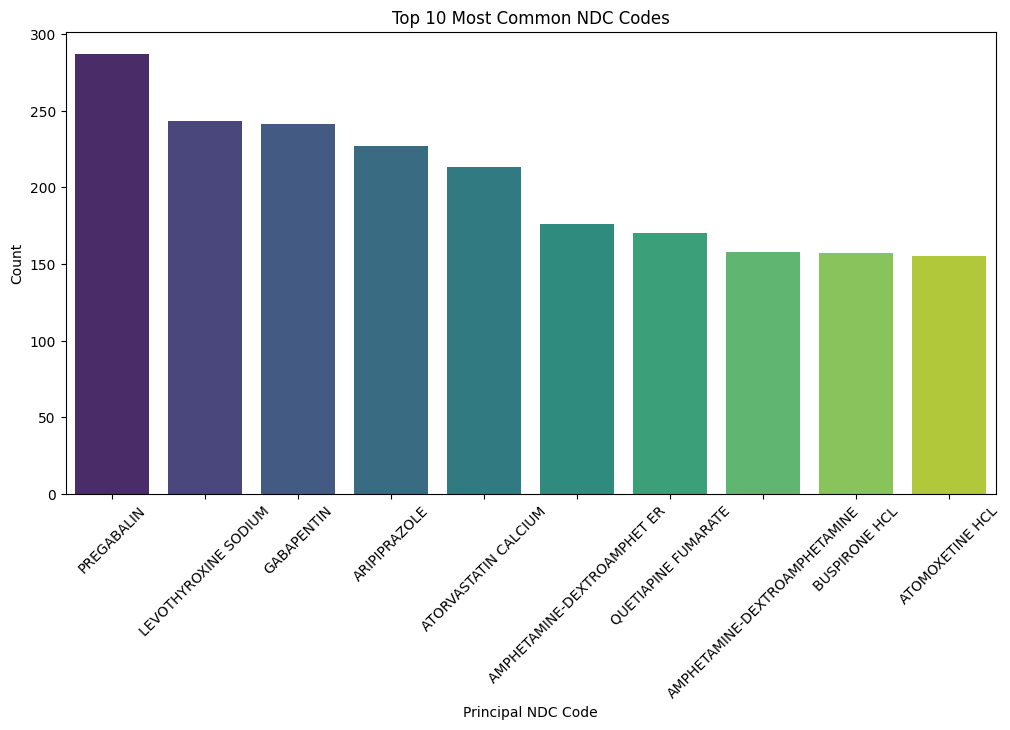

In [24]:
# Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_drugs.index, y=top_10_drugs.values, palette="viridis")
plt.xlabel("Principal NDC Code")
plt.ylabel("Count")
plt.title("Top 10 Most Common NDC Codes")
plt.xticks(rotation=45)
plt.show()

Top 10 Diagnoses with Highest Mean Total Paid Amount:
principal_diagnosis_code
F72   72517.11
F73   71777.39
F71   64043.71
F70   52844.15
F78   38752.07
G12   35107.17
D83   31389.33
D66   27713.29
Q20   27433.71
G61   26488.88
Name: total_paid_amt_mean, dtype: float64


<ipython-input-5-ca8f285c2a53>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="principal_diagnosis_code", y="total_paid_amt_mean", data=df_top_10, palette="coolwarm")


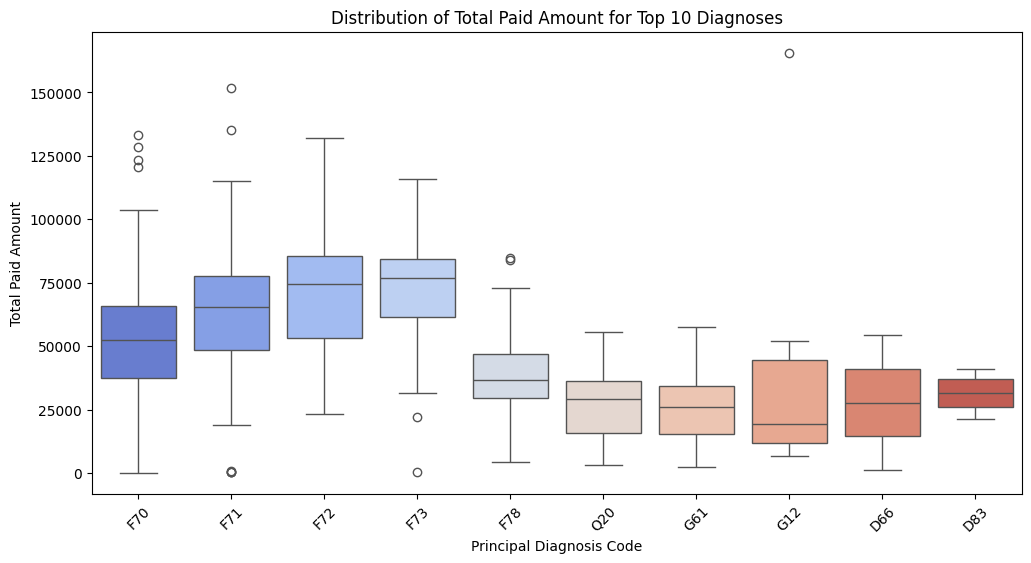

In [5]:
### 2. Diagnosis vs. Total Paid Amount ###
# Group by diagnosis code and calculate the mean total paid amount
diagnosis_paid_mean = df.groupby('principal_diagnosis_code')['total_paid_amt_mean'].mean().nlargest(10)
print("Top 10 Diagnoses with Highest Mean Total Paid Amount:")
print(diagnosis_paid_mean)

# Boxplot for top 5 diagnoses
top_10_diagnoses = diagnosis_paid_mean.index
df_top_10 = df[df['principal_diagnosis_code'].isin(top_10_diagnoses)]

plt.figure(figsize=(12, 6))
sns.boxplot(x="principal_diagnosis_code", y="total_paid_amt_mean", data=df_top_10, palette="coolwarm")
plt.xlabel("Principal Diagnosis Code")
plt.ylabel("Total Paid Amount")
plt.title("Distribution of Total Paid Amount for Top 10 Diagnoses")
plt.xticks(rotation=45)
plt.show()

In [6]:
### 3. Diagnoses by Age Group ###
# Create a contingency table
contingency_table = pd.crosstab(df['age_group_name'], df['principal_diagnosis_code'])

# Identify top 3 diagnoses for each age group
top_3_by_age = df.groupby('age_group_name')['principal_diagnosis_code'].value_counts().groupby(level=0).head(3)
print("Top 3 Diagnoses for Each Age Group:")
print(top_3_by_age)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square Test Result: χ²={chi2:.2f}, p-value={p:.4f}")
if p < 0.05:
    print("Significant difference in diagnosis distribution across age groups.")
else:
    print("No significant difference in diagnosis distribution across age groups.")

Top 3 Diagnoses for Each Age Group:
age_group_name      principal_diagnosis_code
18 years and under  Z00                         345
                    Z20                         343
                    Z23                         343
19 to 44 years      Z23                         477
                    Z20                         448
                    Z00                         446
45 to 64 years      Z23                         513
                    I10                         503
                    M25                         503
65 to 74 years      Z23                         399
                    Z00                         354
                    E11                         347
75 years and older  Z23                         298
                    I10                         263
                    E11                         256
Name: count, dtype: int64

Chi-square Test Result: χ²=90831.18, p-value=0.0000
Significant difference in diagnosis distribution across age 

Mean Payment Differences by Diagnosis:
                          insurer_paid_amt_mean  member_paid_amt_mean
principal_diagnosis_code                                             
A04                                     2406.11                163.74
A05                                      296.15                112.79
A08                                      781.29                 84.07
A09                                      774.33                114.83
A15                                     1158.22                 16.53
...                                         ...                   ...
Z95                                      540.66                108.50
Z96                                      279.63                 57.55
Z97                                      129.03                 20.73
Z98                                      364.08                 72.97
Z99                                      734.31                 21.29

[1206 rows x 2 columns]

Mean Payment Differences 

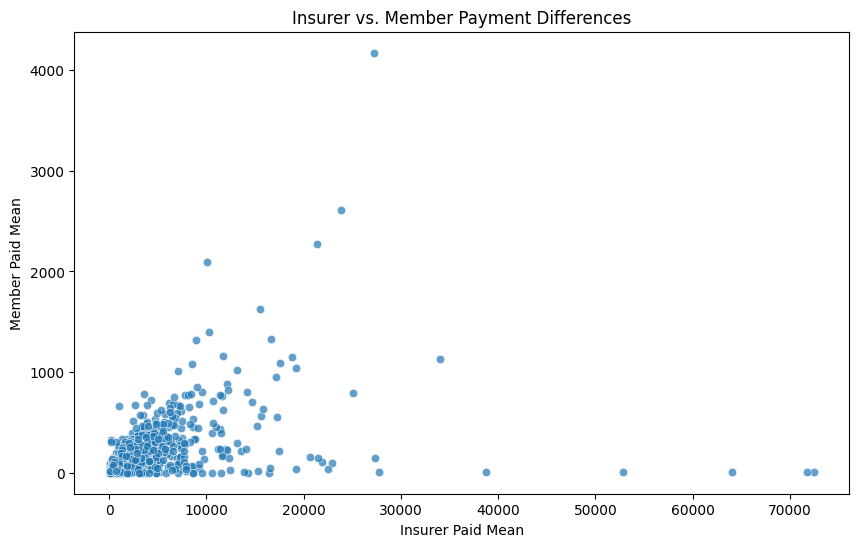

In [7]:
### 4. Insurer vs. Member Payment Differences ###
# Group by diagnosis code and calculate means
payment_means = df.groupby('principal_diagnosis_code')[['insurer_paid_amt_mean', 'member_paid_amt_mean']].mean()
print("Mean Payment Differences by Diagnosis:")
print(payment_means)

# Create a delta between insurer_paid_amt_mean and member_paid_amt_mean
payment_means['delta'] = payment_means['insurer_paid_amt_mean'] - payment_means['member_paid_amt_mean']
print("\nMean Payment Differences with Delta:")
print(payment_means)

# Top diagnoses with highest member out-of-pocket costs
top_member_paid = payment_means['member_paid_amt_mean'].nlargest(5)
print("\nTop 5 Diagnoses with Highest Member Out-of-Pocket Costs:")
print(top_member_paid)

# Top diagnoses with highest delta between insurer and member
top_delta = payment_means['delta'].nlargest(5)
print("\nTop 5 Diagnoses with Highest Delta Between Insurer and Member:")
print(top_delta)

# Scatter plot: Insurer Paid vs. Member Paid
plt.figure(figsize=(10, 6))
sns.scatterplot(x='insurer_paid_amt_mean', y='member_paid_amt_mean', data=payment_means, alpha=0.7)
plt.xlabel("Insurer Paid Mean")
plt.ylabel("Member Paid Mean")
plt.title("Insurer vs. Member Payment Differences")
plt.show()